<a href="https://colab.research.google.com/github/nagarsourabh717/Celebel_Internship_2026/blob/main/Copy_of_week1_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Week 1 Assignment — ML Foundations

**Topics Covered:** Python · NumPy · Pandas · Linear Algebra · Statistics · Probability Theory

---

> Complete all cells. Where marked `# YOUR CODE HERE`, write your solution. Do not change cell types or remove assertion blocks.

In [ ]:
# ── Setup ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from io import StringIO

plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('All imports OK ✓')

All imports OK ✓


---
## Part 1 — Python Fundamentals

### 1.1 Data Types & Control Flow

Write a function `classify_number(n)` that:
- Returns `"negative"` if `n < 0`
- Returns `"zero"` if `n == 0`
- Returns `"small positive"` if `0 < n <= 10`
- Returns `"large positive"` otherwise

In [ ]:
def classify_number(n):
    # YOUR CODE HERE
    if n < 0:
        return "negative"
    elif n == 0:
        return "zero"
    elif 0 < n <= 10:
        return "small positive"
    else:
        return "large positive"
    pass

# Tests
assert classify_number(-5) == "negative"
assert classify_number(0)  == "zero"
assert classify_number(7)  == "small positive"
assert classify_number(42) == "large positive"
print("1.1 passed ✓")

1.1 passed ✓


### 1.2 Data Structures

Given the list `words = ['apple', 'banana', 'cherry', 'apple', 'date', 'banana', 'apple']`:

1. Build a **dict** `word_count` mapping each word to its frequency using only a loop (no `Counter`).
2. Using a **set**, find all unique words and store in `unique_words`.
3. Using a **list comprehension**, build `long_words` containing words with more than 5 characters.

In [ ]:
words = ['apple', 'banana', 'cherry', 'apple', 'date', 'banana', 'apple']

# 1. word_count dict
word_count = {}
# YOUR CODE HERE
for word in words:
    if word in word_count:
        word_count[word] += 1
    else:
        word_count[word] = 1

# 2. unique_words set
unique_words = None  # YOUR CODE HERE
unique_words = set(words)

# 3. long_words list comprehension
long_words = None  # YOUR CODE HERE
long_words = [word for word in words if len(word) > 5]

# Tests
assert word_count == {'apple': 3, 'banana': 2, 'cherry': 1, 'date': 1}
assert unique_words == {'apple', 'banana', 'cherry', 'date'}
assert set(long_words) == {'banana', 'cherry'}
print("1.2 passed ✓")

1.2 passed ✓


### 1.3 Exceptions

Write `safe_divide(a, b)` that:
- Returns `a / b` normally
- Returns `None` if `b == 0` (catch `ZeroDivisionError`)
- Raises `TypeError` with message `"Inputs must be numeric"` if either input is not a number

In [ ]:
def safe_divide(a, b):
    # YOUR CODE HERE
    if not (isinstance(a, (int, float)) and isinstance(b, (int, float))):
        raise TypeError("Inputs must be numeric")
    try:
        return a / b
    except ZeroDivisionError:
        return None
    pass

# Tests
assert safe_divide(10, 2) == 5.0
assert safe_divide(5, 0) is None
try:
    safe_divide('x', 2)
    assert False, "Should have raised TypeError"
except TypeError as e:
    assert str(e) == "Inputs must be numeric"
print("1.3 passed ✓")

1.3 passed ✓


### 1.4 Functions & Lambdas

1. Write a function `apply_twice(f, x)` that applies function `f` to `x` twice: `f(f(x))`.
2. Using a **lambda**, create `triple` that multiplies its input by 3.
3. Demonstrate: `apply_twice(triple, 4)` should return `36`.

In [ ]:
def apply_twice(f, x):
    # YOUR CODE HERE
    return f(f(x))
    pass

triple = None  # YOUR CODE HERE (lambda)
triple = lambda x: x * 3

result = apply_twice(triple, 4)
assert result == 36, f"Expected 36, got {result}"
print("1.4 passed ✓")

1.4 passed ✓


---
## Part 2 — NumPy

### 2.1 Array Creation & Shapes

1. Create a 1D array `arr1d` of integers 0–11.
2. Reshape it into a 2D array `arr2d` of shape `(3, 4)`.
3. Reshape `arr1d` into a 3D array `arr3d` of shape `(2, 2, 3)`.
4. Print the shape, ndim, and dtype of each.

In [ ]:
import numpy as np

# YOUR CODE HERE
arr1d = np.arange(12)
arr2d = arr1d.reshape(3, 4)
arr3d = arr1d.reshape(2, 2, 3)

# Tests
assert arr1d.shape == (12,)
assert arr2d.shape == (3, 4)
assert arr3d.shape == (2, 2, 3)

print("2.1 passed ✓")
print(f"arr2d:\n{arr2d}")
print(f"arr3d:\n{arr3d}")

2.1 passed ✓
arr2d:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
arr3d:
[[[ 0  1  2]
  [ 3  4  5]]

 [[ 6  7  8]
  [ 9 10 11]]]


### 2.2 Indexing & Slicing

Using `arr2d` from above:
1. Extract the **second row** → `row2`
2. Extract the **third column** → `col3`
3. Extract the **bottom-right 2×2 submatrix** → `sub`
4. Use **boolean indexing** to get all elements greater than 7 → `gt7`

In [ ]:
# YOUR CODE HERE
row2 = arr2d[1]          # second row
col3 = arr2d[:, 2]       # third column
sub  = arr2d[1:, 2:]     # bottom-right 2x2
gt7  = arr2d[arr2d > 7]  # elements > 7

# Tests
assert list(row2) == [4, 5, 6, 7]
assert list(col3) == [2, 6, 10]
assert sub.shape == (2, 2)
assert list(gt7) == [8, 9, 10, 11]

print("2.2 passed ✓")

2.2 passed ✓


### 2.3 Operations & Dot Product

Given:
```
A = [[1, 2], [3, 4]]
B = [[5, 6], [7, 8]]
```

1. Compute **element-wise product** `C = A * B`
2. Compute **matrix multiplication** `D = A @ B`
3. Compute the **dot product** of vectors `[1,2,3]` and `[4,5,6]` → `dp`
4. Multiply all elements of `A` by scalar 3 → `E`

In [ ]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

C  = None  # YOUR CODE HERE
C=A*B
D  = None  # YOUR CODE HERE
D=A@B
dp = None  # YOUR CODE HERE
dp=np.dot([1,2,3],[4,5,6])
E  = None  # YOUR CODE HERE
E=A*3

# Tests
assert np.array_equal(C, [[5,12],[21,32]])
assert np.array_equal(D, [[19,22],[43,50]])
assert dp == 32
assert np.array_equal(E, [[3,6],[9,12]])
print("2.3 passed ✓")

2.3 passed ✓


---
## Part 3 — Pandas

In [ ]:
# Load dataset — do not modify this cell
import pandas as pd
from io import StringIO
CSV_DATA = """employee_id,name,department,salary,age,years_exp,performance
1,Alice,Engineering,95000,30,5,4.2
2,Bob,Marketing,72000,35,8,3.8
3,Carol,Engineering,88000,28,3,4.5
4,Dave,HR,61000,42,15,3.1
5,Eve,Engineering,102000,38,12,4.8
6,Frank,Marketing,68000,29,4,3.5
7,Grace,HR,,31,6,3.9
8,Hank,Engineering,91000,45,20,4.1
9,Iris,Marketing,75000,,7,4.0
10,Jack,Engineering,85000,33,8,
"""
df = pd.read_csv(StringIO(CSV_DATA))
print(f"Shape: {df.shape}")
df.head()

Shape: (10, 7)


,employee_id,name,department,salary,age,years_exp,performance
0,1,Alice,Engineering,95000.0,30.0,5,4.2
1,2,Bob,Marketing,72000.0,35.0,8,3.8
2,3,Carol,Engineering,88000.0,28.0,3,4.5
3,4,Dave,HR,61000.0,42.0,15,3.1
4,5,Eve,Engineering,102000.0,38.0,12,4.8


### 3.1 DataFrames vs Series

1. Extract the `salary` column as a **Series** → `salary_series`
2. Extract `name` and `department` columns as a **DataFrame** → `name_dept_df`
3. Print the type of each to confirm.

In [ ]:
salary_series = None  # YOUR CODE HERE
salary_series = df['salary']
name_dept_df  = None  # YOUR CODE HERE
name_dept_df  = df[['name', 'department']]

assert isinstance(salary_series, pd.Series)
assert isinstance(name_dept_df, pd.DataFrame)
print(f"salary_series type: {type(salary_series).__name__}")
print(f"name_dept_df type: {type(name_dept_df).__name__}")
print("3.1 passed ✓")

salary_series type: Series
name_dept_df type: DataFrame
3.1 passed ✓


### 3.2 iloc & loc

1. Use `iloc` to select rows 2–4 (inclusive), columns 0–2 → `iloc_result`
2. Use `loc` to select rows where index is 5 or 6, columns `name` and `salary` → `loc_result`

In [ ]:
iloc_result = None  # YOUR CODE HERE
iloc_result = df.iloc[1:4, :3]
loc_result  = None  # YOUR CODE HERE
loc_result  = df.loc[(df.index == 5) | (df.index == 6), ['name', 'salary']]
assert iloc_result.shape == (3, 3)
assert list(loc_result.columns) == ['name', 'salary']
print("3.2 passed ✓")
display(iloc_result)
display(loc_result)

3.2 passed ✓


,employee_id,name,department
1,2,Bob,Marketing
2,3,Carol,Engineering
3,4,Dave,HR


,name,salary
5,Frank,68000.0
6,Grace,NaN


### 3.3 Filtering & Group By

1. Filter employees in **Engineering** with **salary > 90000** → `senior_eng`
2. Group by `department` and compute mean salary and mean performance → `dept_stats`
3. Sort `dept_stats` by mean salary descending.

In [ ]:
senior_eng = None  # YOUR CODE HERE
senior_eng = df[(df['department'] == 'Engineering') & (df['salary'] > 90000)]
dept_stats = None  # YOUR CODE HERE (groupby + agg + sort)
dept_stats = df.groupby('department').agg({'salary': 'mean', 'performance': 'mean'}).sort_values(by='salary', ascending=False)
print(f"Senior engineers: {len(senior_eng)}")
display(senior_eng[['name','salary']])
print("\nDept stats:")
display(dept_stats)

Senior engineers: 3


,name,salary
0,Alice,95000.0
4,Eve,102000.0
7,Hank,91000.0



Dept stats:


,salary,performance
department,,
Engineering,92200.000000,4.400000
Marketing,71666.666667,3.766667
HR,61000.000000,3.500000


### 3.4 Handling Missing Data

1. Identify which columns have missing values and how many → print a summary.
2. Fill missing `salary` with the **median salary** → `df_filled`
3. Fill missing `age` with the **mean age** (rounded to nearest int).
4. Drop rows where `performance` is missing.
5. Confirm no nulls remain.

In [ ]:
# 1. Missing values summary (column-wise)
missing_summary = df.isnull().sum()
print("Missing values per column:\n", missing_summary)

# 2. Fill missing salary with median
df_filled = df.copy()
df_filled['salary'] = df_filled['salary'].fillna(df_filled['salary'].median())

# 3. Fill missing age with mean (rounded)
mean_age = round(df_filled['age'].mean())
df_filled['age'] = df_filled['age'].fillna(mean_age)

# 4. Drop rows where performance is missing
df_filled = df_filled.dropna(subset=['performance'])

# 5. Confirm no nulls remain
print("\nNulls after cleaning:\n", df_filled.isnull().sum())

Missing values per column:
 employee_id    0
name           0
department     0
salary         1
age            1
years_exp      0
performance    1
dtype: int64

Nulls after cleaning:
 employee_id    0
name           0
department     0
salary         0
age            0
years_exp      0
performance    0
dtype: int64


---
## Part 4 — Linear Algebra

### 4.1 Vectors & Matrices as Data

1. Represent a 2D point `(3, 4)` as a NumPy vector and compute its **L2 norm** (Euclidean length).
2. Create a 3×3 matrix `M` (use any non-trivial values).
3. Plot the vector as an arrow from the origin using `matplotlib` — label axes and title it *"Vector Visualization"*.

L2 Norm: 5.0

Matrix M:
 [[ 2 -1  3]
 [ 0  4  5]
 [ 7  1 -2]]


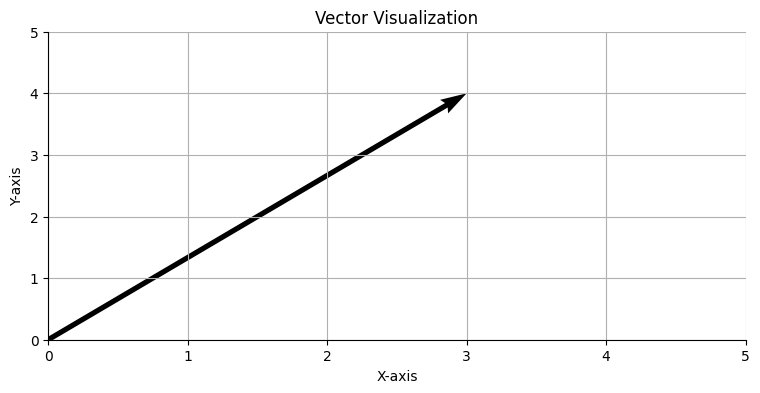

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Represent point (3, 4) as vector
v = np.array([3, 4])

# 2. Compute L2 norm (Euclidean length)
l2_norm = np.linalg.norm(v)
print("L2 Norm:", l2_norm)   # Expected: 5.0

# 3. Create a 3x3 matrix (non-trivial values)
M = np.array([
    [2, -1, 3],
    [0, 4, 5],
    [7, 1, -2]
])
print("\nMatrix M:\n", M)

# 4. Plot vector as arrow
plt.figure()
plt.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1)
plt.xlim(0, 5)
plt.ylim(0, 5)
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Vector Visualization")
plt.grid()

plt.show()

### 4.2 Matrix Operations in Practice

Let:
```
P = [[2, 1], [0, 3]]
Q = [[1, 4], [2, 0]]
```

1. Compute `P + Q` (matrix addition)
2. Compute `3 * P` (scalar multiplication)
3. Compute `P @ Q` (matrix multiplication)
4. Verify that matrix multiplication is **not commutative** — show `P @ Q ≠ Q @ P`.

In [ ]:
import numpy as np

P = np.array([[2, 1], [0, 3]])
Q = np.array([[1, 4], [2, 0]])

# 1. Matrix Addition
add = P + Q

# 2. Scalar Multiplication
scalar = 3 * P

# 3. Matrix Multiplication
PQ = P @ Q
QP = Q @ P

print("P + Q:\n", add)
print("\n3 * P:\n", scalar)
print("\nP @ Q:\n", PQ)
print("\nQ @ P:\n", QP)

# 4. Verify non-commutative
print("\nIs P @ Q equal to Q @ P? ->", np.array_equal(PQ, QP))

P + Q:
 [[3 5]
 [2 3]]

3 * P:
 [[6 3]
 [0 9]]

P @ Q:
 [[4 8]
 [6 0]]

Q @ P:
 [[ 2 13]
 [ 4  2]]

Is P @ Q equal to Q @ P? -> False


### 4.3 Eigenvalues & Eigenvectors

For the matrix:
```
A = [[4, 1],
     [2, 3]]
```

1. Compute eigenvalues and eigenvectors using `np.linalg.eig`.
2. **Verify** the eigenvector equation: `A @ v = λ * v` for each eigenpair.
3. Plot both eigenvectors as arrows, scaled by their eigenvalues, on a 2D plot.
4. **Explain** in a markdown cell (below): what does it geometrically mean for a matrix to stretch a vector?

Eigenvalues:
 [5. 2.]

Eigenvectors (columns):
 [[ 0.70710678 -0.4472136 ]
 [ 0.70710678  0.89442719]]

Eigenpair 1:
A @ v = [3.53553391 3.53553391]
λ * v = [3.53553391 3.53553391]
Equal? -> True

Eigenpair 2:
A @ v = [-0.89442719  1.78885438]
λ * v = [-0.89442719  1.78885438]
Equal? -> True


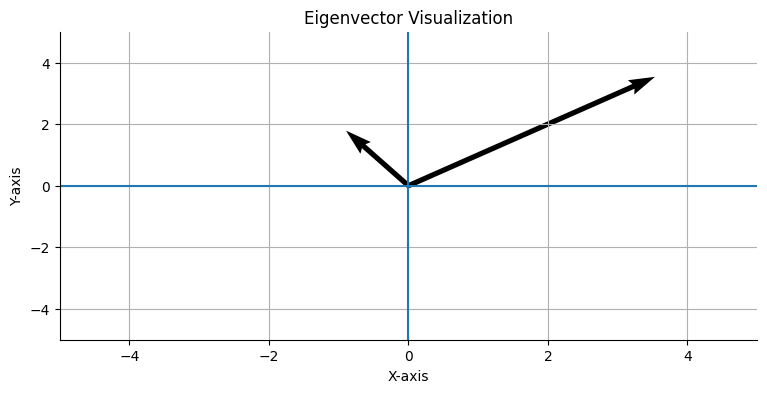

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Matrix A
A = np.array([[4, 1],
              [2, 3]])

# 1. Eigenvalues & Eigenvectors
eigvals, eigvecs = np.linalg.eig(A)

print("Eigenvalues:\n", eigvals)
print("\nEigenvectors (columns):\n", eigvecs)

# 2. Verify A @ v = λ * v
for i in range(len(eigvals)):
    v = eigvecs[:, i]
    lam = eigvals[i]

    left = A @ v
    right = lam * v

    print(f"\nEigenpair {i+1}:")
    print("A @ v =", left)
    print("λ * v =", right)
    print("Equal? ->", np.allclose(left, right))

# 3. Plot eigenvectors scaled by eigenvalues
plt.figure()

for i in range(len(eigvals)):
    v = eigvecs[:, i]
    lam = eigvals[i]

    # scale vector by eigenvalue
    vec = lam * v
    plt.quiver(0, 0, vec[0], vec[1], angles='xy', scale_units='xy', scale=1)

plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.axhline(0)
plt.axvline(0)
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Eigenvector Visualization")
plt.grid()

plt.show()

**Your Geometric Explanation (4.3):**

> *Replace this text with your explanation of what eigenvalues/eigenvectors mean geometrically — what does it mean for a matrix to "stretch" or "squish" a vector?*

### 4.4 SVD & Dimensionality Reduction

1. Create a random 4×3 matrix `X` (use `np.random.seed(42)`).
2. Compute its **SVD**: `U, S, Vt = np.linalg.svd(X, full_matrices=False)`.
3. **Reconstruct** `X` from the SVD and verify it matches the original.
4. Perform a **rank-1 approximation** using only the largest singular value/vector — call it `X_approx`.
5. Explain the relationship between SVD components and PCA in the markdown cell below.

In [ ]:
import numpy as np

# 1. Create random 4x3 matrix
np.random.seed(42)
X = np.random.rand(4, 3)

# 2. Compute SVD
U, S, Vt = np.linalg.svd(X, full_matrices=False)

print("X:\n", X)
print("\nU:\n", U)
print("\nSingular values S:\n", S)
print("\nVt:\n", Vt)

# 3. Reconstruct X
X_reconstructed = U @ np.diag(S) @ Vt
print("\nReconstruction close?", np.allclose(X, X_reconstructed))

# 4. Rank-1 approximation (use only largest singular value)
S1 = np.zeros_like(S)
S1[0] = S[0]   # keep only largest singular value

X_approx = U @ np.diag(S1) @ Vt

print("\nRank-1 Approximation:\n", X_approx)

X:
 [[0.37454012 0.95071431 0.73199394]
 [0.59865848 0.15601864 0.15599452]
 [0.05808361 0.86617615 0.60111501]
 [0.70807258 0.02058449 0.96990985]]

U:
 [[-0.64705491  0.31978242 -0.18315965]
 [-0.23766949 -0.32542636 -0.86085197]
 [-0.50284277  0.50336944  0.19246886]
 [-0.52151922 -0.73379568  0.43398406]]

Singular values S:
 [1.88660776 0.90837245 0.40010191]

Vt:
 [[-0.4150896  -0.58227835 -0.69903687]
 [-0.62242198  0.74215255 -0.248597  ]
 [-0.66354464 -0.33190589  0.67048265]]

Reconstruction close? True

Rank-1 Approximation:
 [[0.50671599 0.71080979 0.85334144]
 [0.18612166 0.26108727 0.31344052]
 [0.39378184 0.5523883  0.66315326]
 [0.40840758 0.57290496 0.68778393]]


**SVD → PCA Connection (4.4):**

> *Explain: what are U, S, Vt in SVD, and how do they relate to principal components? Which matrix contains the directions of maximum variance?*

---
## Part 5 — Statistics

### 5.1 Descriptive vs Inferential Statistics

Using the cleaned `df_filled` from Part 3:

1. Compute **descriptive statistics** for the `salary` column: mean, median, std, min, max, IQR.
2. Plot a **histogram** of salary with a KDE overlay.
3. In the markdown cell below, write one sentence each defining: *population*, *sample*, *descriptive statistic*, *inferential statistic*.

Mean:   81889
Median: 85000
Std:    12827
Range:  61000 – 102000
IQR:    19000


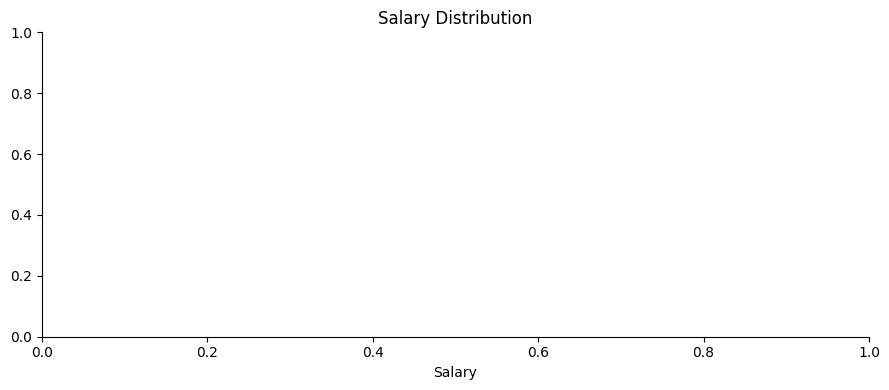

In [ ]:
salary = df_filled['salary']

mean_s   = None  # YOUR CODE HERE
mean_s   = np.mean(salary)
median_s = None  # YOUR CODE HERE
median_s = np.median(salary)
std_s    = None  # YOUR CODE HERE
std_s    = np.std(salary)
min_s    = None  # YOUR CODE HERE
min_s    = np.min(salary)
max_s    = None  # YOUR CODE HERE
max_s    = np.max(salary)
iqr_s    = None  # YOUR CODE HERE — use np.percentile
iqr_s    = np.percentile(salary, 75) - np.percentile(salary, 25)

print(f"Mean:   {mean_s:.0f}")
print(f"Median: {median_s:.0f}")
print(f"Std:    {std_s:.0f}")
print(f"Range:  {min_s:.0f} – {max_s:.0f}")
print(f"IQR:    {iqr_s:.0f}")

# Histogram + KDE
fig, ax = plt.subplots()
# YOUR CODE HERE
ax.set_xlabel('Salary'); ax.set_title('Salary Distribution')
plt.tight_layout(); plt.show()

**Definitions (5.1):**

- **Population:** ...
- **Sample:** ...
- **Descriptive statistic:** ...
- **Inferential statistic:** ...

### 5.2 Hypothesis Testing

**Scenario:** You suspect that Engineering salaries are significantly higher than the company average.

1. State the **null hypothesis H₀** and **alternative hypothesis H₁**.
2. Run a **one-sample t-test** comparing Engineering salaries against the overall mean salary.
3. Interpret the p-value at α = 0.05.
4. Also compute the **Pearson correlation** between `salary` and `years_exp`, and interpret it.

In [ ]:
import numpy as np
from scipy import stats

# Engineering salaries
eng_salary = df_filled[df_filled['department'] == 'Engineering']['salary']

# Overall mean salary
overall_mean = df_filled['salary'].mean()

# 1. One-sample t-test
t_stat, p_value = stats.ttest_1samp(eng_salary, overall_mean)

print("Overall Mean Salary:", overall_mean)
print("Engineering Salaries:\n", eng_salary.values)
print("\nT-statistic:", t_stat)
print("P-value:", p_value)

# 2. Pearson correlation
corr, _ = stats.pearsonr(df_filled['salary'], df_filled['years_exp'])
print("\nPearson Correlation (salary vs years_exp):", corr)

Overall Mean Salary: 81888.88888888889
Engineering Salaries:
 [ 95000.  88000. 102000.  91000.]

T-statistic: 4.0001683466257765
P-value: 0.02800537098696597

Pearson Correlation (salary vs years_exp): 0.04845915903711645


**H₀ / H₁ and Interpretation (5.2):**

- H₀: ...
- H₁: ...
- Conclusion: ...

### 5.3 Error Metrics

Given these predictions and actuals, **implement from scratch** (no sklearn):
- MAE, MSE, RMSE
- R² Score
- Adjusted R² (assume 2 features)

In [ ]:
import numpy as np

# Example (replace with your actual arrays if given)
y_true = np.array([3, -0.5, 2, 7])
y_pred = np.array([2.5, 0.0, 2, 8])

n = len(y_true)
p = 2  # number of features (given)

# 1. MAE
mae = np.mean(np.abs(y_true - y_pred))

# 2. MSE
mse = np.mean((y_true - y_pred) ** 2)

# 3. RMSE
rmse = np.sqrt(mse)

# 4. R² Score
ss_total = np.sum((y_true - np.mean(y_true)) ** 2)
ss_res   = np.sum((y_true - y_pred) ** 2)
r2 = 1 - (ss_res / ss_total)

# 5. Adjusted R²
adj_r2 = 1 - (1 - r2) * ((n - 1) / (n - p - 1))

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)
print("Adjusted R²:", adj_r2)

MAE: 0.5
MSE: 0.375
RMSE: 0.6123724356957945
R²: 0.9486081370449679
Adjusted R²: 0.8458244111349038


### 5.4 Distribution Testing & Stationarity

1. Generate two samples: `s1` ~ Normal(0, 1), `s2` ~ Exponential(1), both n=200 (seed=0).
2. Run the **Kolmogorov-Smirnov test** (`stats.kstest`) comparing each against a standard normal CDF.
3. Generate a non-stationary time series (linear trend + noise). Run the **Augmented Dickey-Fuller test** (`adfuller` from `statsmodels`) and interpret the result.
4. Difference the series once and re-run ADF to confirm stationarity.

In [ ]:
import numpy as np
from scipy import stats
from statsmodels.tsa.stattools import adfuller

# 1. Generate samples
np.random.seed(0)
n = 200

s1 = np.random.normal(0, 1, n)      # Normal(0,1)
s2 = np.random.exponential(1, n)    # Exponential(1)

# 2. Kolmogorov-Smirnov Test (against standard normal)
ks_s1 = stats.kstest(s1, 'norm')
ks_s2 = stats.kstest(s2, 'norm')

print("KS Test (s1 ~ Normal vs Normal):", ks_s1)
print("KS Test (s2 ~ Exp vs Normal):", ks_s2)


# 3. Generate non-stationary time series (trend + noise)
t = np.arange(200)
noise = np.random.normal(0, 1, 200)
ts = 0.5 * t + noise   # linear trend → non-stationary

# ADF test
adf_result = adfuller(ts)
print("\nADF Test (Original Series):")
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

# 4. Difference the series
ts_diff = np.diff(ts)

adf_result_diff = adfuller(ts_diff)
print("\nADF Test (After Differencing):")
print("ADF Statistic:", adf_result_diff[0])
print("p-value:", adf_result_diff[1])

KS Test (s1 ~ Normal vs Normal): KstestResult(statistic=np.float64(0.05223930603875537), pvalue=np.float64(0.6268328258704317), statistic_location=np.float64(0.298238174206056), statistic_sign=np.int8(-1))
KS Test (s2 ~ Exp vs Normal): KstestResult(statistic=np.float64(0.504585043919773), pvalue=np.float64(1.12791973745829e-47), statistic_location=np.float64(0.011493253758047458), statistic_sign=np.int8(-1))

ADF Test (Original Series):
ADF Statistic: -0.5143086779726039
p-value: 0.8891938785449169

ADF Test (After Differencing):
ADF Statistic: -8.42883260281016
p-value: 1.8943333440095962e-13


### 5.5 Model Monitoring Concepts

1. Implement `compute_psi(expected, actual, bins=10)` that computes the **Population Stability Index** between two distributions.
2. Simulate a scenario where a model's input distribution shifts and plot both distributions.
3. In the markdown cell, define: *concept drift*, *covariate drift*, PSI thresholds (what values indicate no/minor/major shift), and one trigger for retraining.

PSI Value: 1.4636121887006448


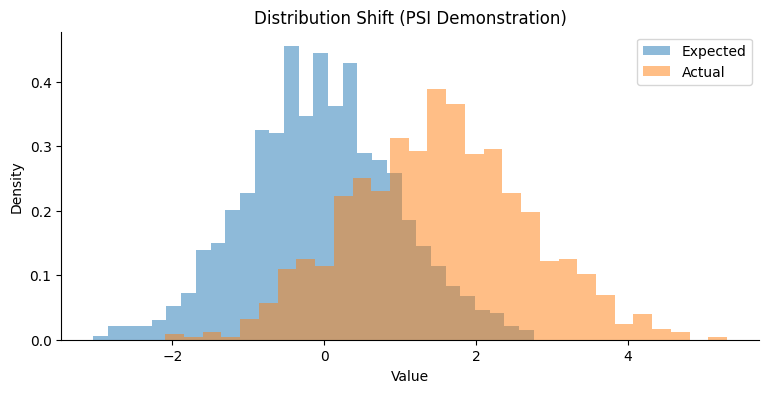

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. PSI Function
def compute_psi(expected, actual, bins=10):
    expected = np.array(expected)
    actual = np.array(actual)

    # Create bins based on expected distribution
    breakpoints = np.linspace(0, 100, bins + 1)
    breakpoints = np.percentile(expected, breakpoints)

    # Histogram counts
    expected_counts, _ = np.histogram(expected, bins=breakpoints)
    actual_counts, _ = np.histogram(actual, bins=breakpoints)

    # Convert to proportions (avoid division by zero)
    expected_perc = expected_counts / len(expected)
    actual_perc = actual_counts / len(actual)

    # Replace zeros to avoid log issues
    expected_perc = np.where(expected_perc == 0, 1e-6, expected_perc)
    actual_perc = np.where(actual_perc == 0, 1e-6, actual_perc)

    # PSI formula
    psi = np.sum((expected_perc - actual_perc) * np.log(expected_perc / actual_perc))

    return psi


# 2. Simulate distribution shift
np.random.seed(0)

expected = np.random.normal(0, 1, 1000)   # original
actual   = np.random.normal(1.5, 1.2, 1000)  # shifted distribution

psi_value = compute_psi(expected, actual)
print("PSI Value:", psi_value)


# 3. Plot distributions
plt.figure()

plt.hist(expected, bins=30, density=True, alpha=0.5, label='Expected')
plt.hist(actual, bins=30, density=True, alpha=0.5, label='Actual')

plt.legend()
plt.title("Distribution Shift (PSI Demonstration)")
plt.xlabel("Value")
plt.ylabel("Density")

plt.show()

**Concept Drift vs Covariate Drift & PSI Thresholds (5.5):**

- **Concept drift:** ...
- **Covariate drift:** ...
- **PSI < 0.1:** ...
- **PSI 0.1–0.2:** ...
- **PSI > 0.2:** ...
- **Retraining trigger example:** ...

---
## Part 6 — Probability Theory

### 6.1 Core Concepts

A bag contains: 4 red, 3 blue, 3 green marbles.

1. Define the sample space and compute P(red), P(blue), P(green).
2. Two marbles drawn **without replacement**. Compute:
   - P(first=red, second=blue) — **joint probability**
   - P(second=blue | first=red) — **conditional probability**
3. Are the two draws **independent**? Show mathematically.

In [ ]:
total = 10
red, blue, green = 4, 3, 3

# Basic probabilities
p_red   = red / total
p_blue  = blue / total
p_green = green / total

# Joint: P(red first AND blue second)
p_red_then_blue = (red / total) * (blue / (total - 1))

# Conditional: P(blue second | red first)
p_blue_given_red = blue / (total - 1)

# Independence check: P(B|A) == P(B) ?
independent = (p_blue_given_red == p_blue)

print(f"P(red)={p_red:.3f}, P(blue)={p_blue:.3f}, P(green)={p_green:.3f}")
print(f"P(red,blue): {p_red_then_blue:.4f}")
print(f"P(blue|red): {p_blue_given_red:.4f}")
print(f"P(blue):     {p_blue:.4f}")
print(f"Independent? {independent}")

P(red)=0.400, P(blue)=0.300, P(green)=0.300
P(red,blue): 0.1333
P(blue|red): 0.3333
P(blue):     0.3000
Independent? False


### 6.2 Distributions in the Wild

1. **Normal**: Plot N(μ=0, σ=1) and N(μ=2, σ=0.5) PDFs on the same axes.
2. **Binomial**: A coin is flipped 20 times. Plot the PMF for k=0..20 with p=0.5 and p=0.7.
3. **Poisson**: Average 3 customers/minute. Plot the PMF for k=0..15.
4. For each, write one real-world ML use case in comments.

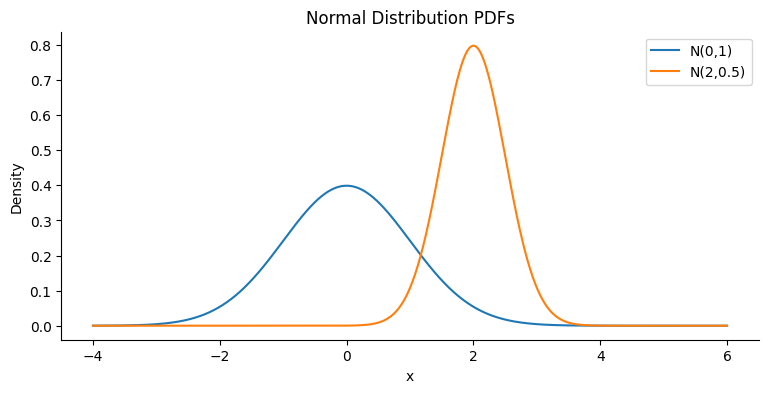

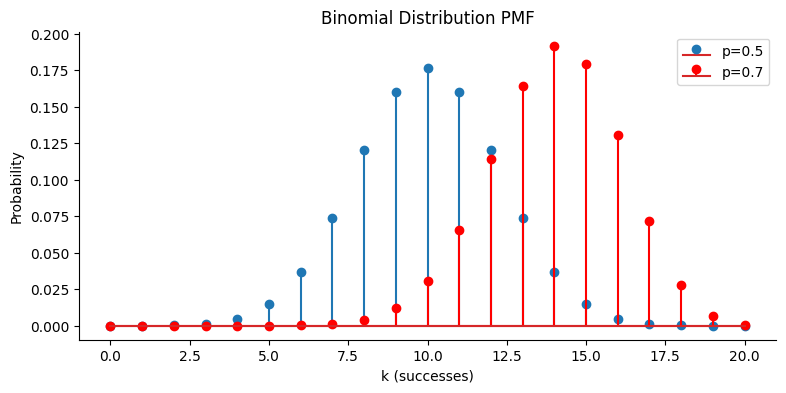

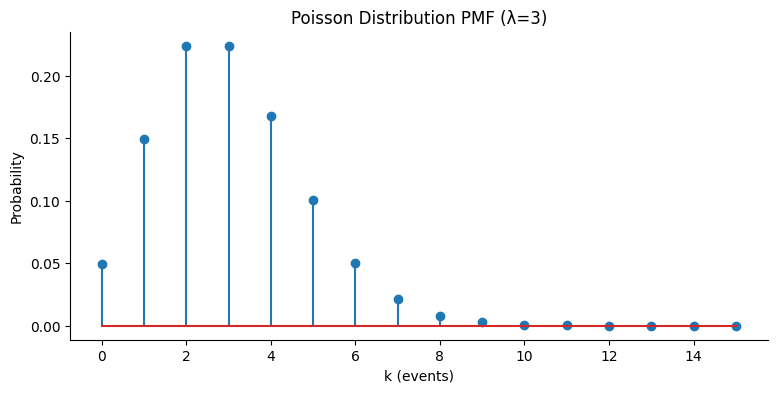

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, binom, poisson

# ---------------- NORMAL DISTRIBUTION ----------------
x = np.linspace(-4, 6, 1000)

pdf1 = norm.pdf(x, 0, 1)      # N(0,1)
pdf2 = norm.pdf(x, 2, 0.5)    # N(2,0.5)

plt.figure()
plt.plot(x, pdf1, label='N(0,1)')
plt.plot(x, pdf2, label='N(2,0.5)')
plt.title("Normal Distribution PDFs")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.show()

# ML Use Case:
# Normal distribution is used in Gaussian Naive Bayes and modeling continuous features.


# ---------------- BINOMIAL DISTRIBUTION ----------------
k_bin = np.arange(0, 21)

pmf_p05 = binom.pmf(k_bin, 20, 0.5)
pmf_p07 = binom.pmf(k_bin, 20, 0.7)

plt.figure()
plt.stem(k_bin, pmf_p05, label='p=0.5')
plt.stem(k_bin, pmf_p07, label='p=0.7', linefmt='r-', markerfmt='ro')
plt.title("Binomial Distribution PMF")
plt.xlabel("k (successes)")
plt.ylabel("Probability")
plt.legend()
plt.show()

# ML Use Case:
# Binomial distribution is used in classification problems (e.g., success/failure outcomes).


# ---------------- POISSON DISTRIBUTION ----------------
k_pois = np.arange(0, 16)

pmf_poisson = poisson.pmf(k_pois, 3)

plt.figure()
plt.stem(k_pois, pmf_poisson)   # FIXED (no use_line_collection)
plt.title("Poisson Distribution PMF (λ=3)")
plt.xlabel("k (events)")
plt.ylabel("Probability")
plt.show()

# ML Use Case:
# Poisson distribution is used for modeling count data (e.g., number of arrivals, clicks).

### 6.3 Bayes' Theorem

**Scenario — Spam filter:**
- P(Spam) = 0.30 (prior)
- P("free" | Spam) = 0.80 (likelihood)
- P("free" | Not Spam) = 0.05

1. Compute P(Spam | "free") using Bayes' theorem.
2. Implement a simple `naive_bayes_predict(prior_spam, p_word_given_spam, p_word_given_ham)` that returns the posterior P(Spam | word).
3. In the markdown cell, map each term — **prior, likelihood, evidence, posterior** — to the spam example.

In [ ]:
p_spam            = 0.30
p_free_given_spam = 0.80
p_free_given_ham  = 0.05
p_ham             = 1 - p_spam

# P(free) — law of total probability
p_free = None  # YOUR CODE HERE

# Bayes
p_spam_given_free = None  # YOUR CODE HERE

print(f"P('free'): {p_free:.4f}")
print(f"P(Spam | 'free'): {p_spam_given_free:.4f}")

def naive_bayes_predict(prior_spam, p_word_given_spam, p_word_given_ham):
    # YOUR CODE HERE
    pass

pred = naive_bayes_predict(0.30, 0.80, 0.05)
assert abs(pred - p_spam_given_free) < 1e-9
print(f"naive_bayes_predict: {pred:.4f}")
print("6.3 passed ✓")

TypeError: unsupported format string passed to NoneType.__format__

**Bayes Term Mapping (6.3):**

| Term | Formula | In this example |
|------|---------|-----------------|
| Prior | P(Spam) | ... |
| Likelihood | P(word \| Spam) | ... |
| Evidence | P(word) | ... |
| Posterior | P(Spam \| word) | ... |

### 6.4 Central Limit Theorem

1. Define a population following an **exponential distribution** (λ=1, size=100,000).
2. Repeatedly draw samples of size `n=30` and record their means — do this 5,000 times.
3. Plot the histogram of sample means.
4. Overlay the **theoretical normal distribution** predicted by the CLT: μ = population mean, σ = population_std / sqrt(n).
5. Run a KS test to confirm the distribution of sample means is approximately normal.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(7)
population = np.random.exponential(scale=1.0, size=100_000)

n_samples = 5000
sample_size = 30

# Generate 5000 sample means
sample_means = np.array([
    np.mean(np.random.choice(population, size=sample_size))
    for _ in range(n_samples)
])

pop_mean = population.mean()
pop_std  = population.std()

# CLT predicted std
clt_std = pop_std / np.sqrt(sample_size)

print(f"Population mean: {pop_mean:.4f}, Population std: {pop_std:.4f}")
print(f"Sample means mean: {sample_means.mean():.4f}, std: {sample_means.std():.4f}")
print(f"CLT predicted std: {clt_std:.4f}")

# Plot
fig, ax = plt.subplots()

# Histogram
ax.hist(sample_means, bins=40, density=True, alpha=0.6, label='Sample Means')

# Theoretical Normal Overlay
x = np.linspace(min(sample_means), max(sample_means), 1000)
pdf = stats.norm.pdf(x, pop_mean, clt_std)
ax.plot(x, pdf, label='CLT Normal', linewidth=2)

ax.set_title('CLT: Distribution of Sample Means')
ax.set_xlabel('Sample Mean')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.show()

# KS test
ks_result = stats.kstest(sample_means, 'norm', args=(pop_mean, clt_std))
print(f"KS test p-value: {ks_result.pvalue:.4f} → Approximately normal? {ks_result.pvalue > 0.05}")

**CLT Reflection (6.4):**

> *In 2–3 sentences: Why does this result matter for statistics and machine learning? What assumption does the CLT justify in many classical statistical tests?*

---
## 🏁 Submission Checklist

Before submitting, verify:

- [ ] All `assert` blocks pass without errors
- [ ] All `# YOUR CODE HERE` cells are filled
- [ ] All markdown reflection cells are filled in your own words
- [ ] All plots render with labels and titles
- [ ] Notebook runs cleanly from top to bottom (`Kernel → Restart & Run All`)

**Save as:** `week1_<your_name>.ipynb`